In [2]:
pip install pyodbc


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pyodbc as odbc
DRIVER_NAME='SQL Server'
SERVER_NAME='LAPTOP-GJ537S6H\SQLEXPRESS'
DATABASE_NAME='GLBajaj'

#uid=<username>;
#pwd=<password>;

connection_string=f"""
      DRIVER={{{DRIVER_NAME}}};
      SERVER={{{SERVER_NAME}}};
      DATABASE={{{DATABASE_NAME}}};
      Trust_Connection=yes;
"""

conn=odbc.connect(connection_string)
print(conn)

In [11]:
import pandas as pd
query = "SELECT * FROM dbo.MegaMart"
df = pd.read_sql(query, conn)

print(df.to_string())

     order_id user_id  order_date  product_id product_category          product_name  quantity  price_per_unit payment_method order_status
0        1001    U188  2025-04-20       940.0          Fashion              Sneakers         2       58.529999         PayPal    Cancelled
1        1002    U062  2025-04-16       794.0          Fashion               T-Shirt         3       83.760002            UPI     Returned
2        1003    U058  2025-04-18       326.0          Fashion            Sunglasses         2       78.849998         PayPal   Processing
3        1004    U011  2025-04-10       574.0          Fashion            Sunglasses         5       46.490002         PayPal    Delivered
4        1005    U003  2025-04-19       988.0       Home Decor           Photo Frame         2       78.610001         PayPal     Returned
5        1006    U017  2025-04-15       328.0          Kitchen             Knife Set         4       53.509998    Credit Card     Returned
6        1007    U129  2025

C:\Users\KULDEEP SHARMA\AppData\Local\Temp\ipykernel_9692\1290352382.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [17]:
df1.isnull().sum()

order_id            0
user_id             0
order_date          0
product_id          0
product_category    0
product_name        0
quantity            0
price_per_unit      0
payment_method      0
order_status        0
dtype: int64

In [19]:
df1["price_per_unit"].min()

np.float64(12.710000038146973)

In [23]:
df1["price_per_unit"].mean()

np.float64(52.58799982070923)

In [24]:
df1["quantity"].sum()

np.int64(29)

In [25]:
df1.groupby("product_category")["quantity"].sum()

product_category
Fashion       12
Home Decor     8
Kitchen        9
Name: quantity, dtype: int64

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
top_products=df.groupby('product_name')['price_per_unit'].sum().sort_values(ascending=False).head(10)
print(top_products)


product_name
Wall Clock              3003.150008
USB-C Cable             2873.950019
Smartwatch              2658.239991
T-Shirt                 2464.529991
Bluetooth Headphones    2380.930001
Cushion Cover           2353.669997
Data Engineering 101    2341.879996
Wall Art                2299.560007
Spark for Dummies       2295.140001
Blender                 2269.660020
Name: price_per_unit, dtype: float64


C:\Users\KULDEEP SHARMA\AppData\Local\Temp\ipykernel_9692\4131194433.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values,y=top_products.index,palette='viridis')


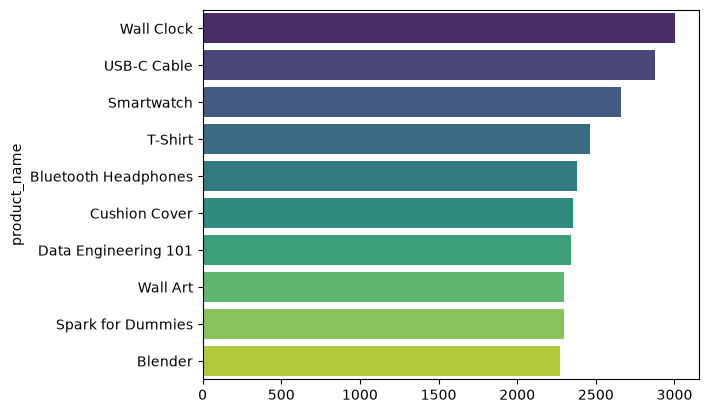

In [10]:
sns.barplot(x=top_products.values,y=top_products.index,palette='viridis')
plt.show()

In [37]:
df1=df.head(20)
df1


,order_id,user_id,order_date,product_id,product_category,product_name,quantity,price_per_unit,payment_method,order_status
0,1001,U188,2025-04-20,940.0,Fashion,Sneakers,2,58.529999,PayPal,Cancelled
1,1002,U062,2025-04-16,794.0,Fashion,T-Shirt,3,83.760002,UPI,Returned
2,1003,U058,2025-04-18,326.0,Fashion,Sunglasses,2,78.849998,PayPal,Processing
3,1004,U011,2025-04-10,574.0,Fashion,Sunglasses,5,46.490002,PayPal,Delivered
4,1005,U003,2025-04-19,988.0,Home Decor,Photo Frame,2,78.610001,PayPal,Returned
5,1006,U017,2025-04-15,328.0,Kitchen,Knife Set,4,53.509998,Credit Card,Returned
6,1007,U129,2025-04-23,786.0,Home Decor,Wall Clock,5,12.710000,Credit Card,Returned
7,1008,U102,2025-04-15,101.0,Home Decor,Photo Frame,1,46.599998,Debit Card,Cancelled
8,1009,U040,2025-04-04,610.0,Kitchen,Toaster,4,35.869999,Credit Card,Processing
9,1010,U186,2025-04-29,354.0,Kitchen,Microwave,1,30.950001,Credit Card,Processing


In [38]:
df2=pd.DataFrame(df1,columns=["order_id","product_name","quantity","price_per_unit"])
df2

,order_id,product_name,quantity,price_per_unit
0,1001,Sneakers,2,58.529999
1,1002,T-Shirt,3,83.760002
2,1003,Sunglasses,2,78.849998
3,1004,Sunglasses,5,46.490002
4,1005,Photo Frame,2,78.610001
5,1006,Knife Set,4,53.509998
6,1007,Wall Clock,5,12.710000
7,1008,Photo Frame,1,46.599998
8,1009,Toaster,4,35.869999
9,1010,Microwave,1,30.950001


In [40]:
df2["Net_price"]=df2["quantity"]*df2["price_per_unit"]
df2

,order_id,product_name,quantity,price_per_unit,Net_price
0,1001,Sneakers,2,58.529999,117.059998
1,1002,T-Shirt,3,83.760002,251.280006
2,1003,Sunglasses,2,78.849998,157.699997
3,1004,Sunglasses,5,46.490002,232.450008
4,1005,Photo Frame,2,78.610001,157.220001
5,1006,Knife Set,4,53.509998,214.039993
6,1007,Wall Clock,5,12.710000,63.550000
7,1008,Photo Frame,1,46.599998,46.599998
8,1009,Toaster,4,35.869999,143.479996
9,1010,Microwave,1,30.950001,30.950001


In [42]:
df2.to_csv("MegaMart_cleanedData.csv", index=False)